100%|██████████| 350/350 [00:05<00:00, 59.88it/s]



       Input                        Sharpened Image

Image 238 - Original vs Blurred: MSE=0.0112, PSNR=19.5192, SSIM=0.8943
Image 238 - Original vs Unblurred: MSE=0.0152, PSNR=18.1684, SSIM=0.8624

Image 155 - Original vs Blurred: MSE=0.0434, PSNR=13.6203, SSIM=0.6636
Image 155 - Original vs Unblurred: MSE=0.0527, PSNR=12.7834, SSIM=0.6235

Image 199 - Original vs Blurred: MSE=0.0543, PSNR=12.6558, SSIM=0.4670
Image 199 - Original vs Unblurred: MSE=0.0690, PSNR=11.6085, SSIM=0.4047


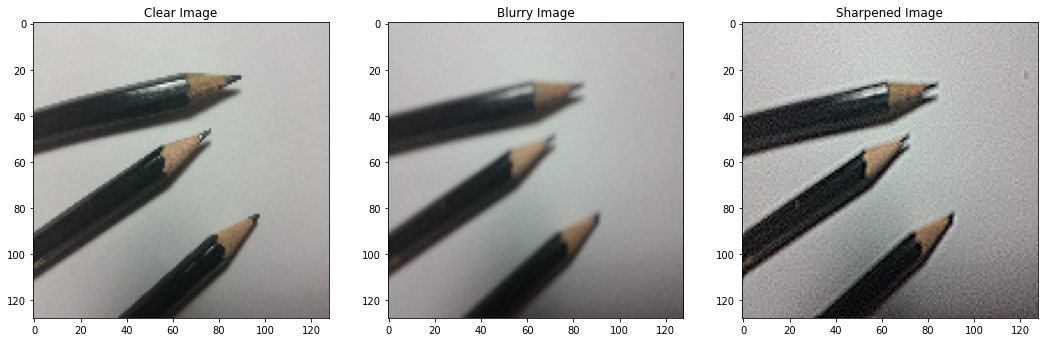

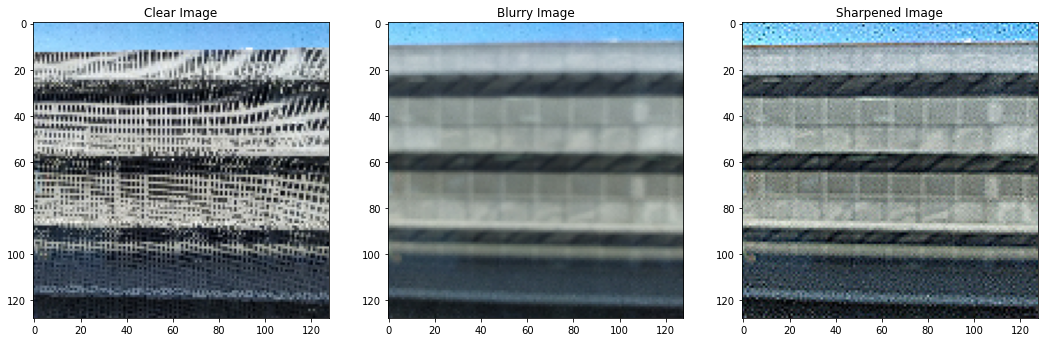

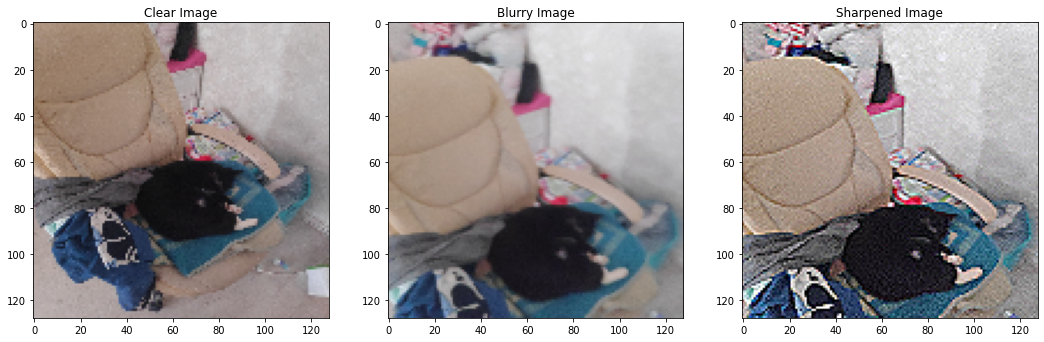

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import cv2
import os
import random
import tensorflow as tf

# Load images from directories
good_frames = 'C:/Users/Mugil/Downloads/imgdataset/sharp'
bad_frames = 'C:/Users/Mugil/Downloads/imgdataset/defocused_blurred'

clean_frames = []
for file in tqdm(sorted(os.listdir(good_frames))):
    if any(extension in file for extension in ['.jpg', 'jpeg', '.png']):
        image = tf.keras.preprocessing.image.load_img(good_frames + '/' + file, target_size=(128,128))
        image = tf.keras.preprocessing.image.img_to_array(image).astype('float32') / 255
        clean_frames.append(image)

clean_frames = np.array(clean_frames)

blurry_frames = []
for file in tqdm(sorted(os.listdir(bad_frames))):
    if any(extension in file for extension in ['.jpg', 'jpeg', '.png']):
        image = tf.keras.preprocessing.image.load_img(bad_frames + '/' + file, target_size=(128,128))
        image = tf.keras.preprocessing.image.img_to_array(image).astype('float32') / 255
        blurry_frames.append(image)

blurry_frames = np.array(blurry_frames)

# Define sharpening filter function
def apply_sharpening_filter(image):
    # Apply sharpening filter
    kernel = np.array([[0, -1, 0],
                       [-1, 5,-1],
                       [0, -1, 0]])
    sharpened = cv2.filter2D(image, -1, kernel)
    return sharpened

# MSE calculation
def mse(imageA, imageB):
    # Mean Squared Error between two images
    return np.mean((imageA - imageB) ** 2)

# PSNR calculation
def psnr(imageA, imageB):
    mse_value = mse(imageA, imageB)
    if mse_value == 0:
        return 100
    PIXEL_MAX = 1.0  # Assuming normalized images (0 to 1 range)
    return 10 * np.log10((PIXEL_MAX ** 2) / mse_value)

# SSIM calculation
def ssim(imageA, imageB):
    C1 = (0.01 * 1.0) ** 2  # Small constant to stabilize division
    C2 = (0.03 * 1.0) ** 2  # Small constant to stabilize division
    
    # Compute means
    muA = np.mean(imageA)
    muB = np.mean(imageB)
    
    # Compute variances
    sigmaA = np.var(imageA)
    sigmaB = np.var(imageB)
    
    # Compute covariance
    sigmaAB = np.mean((imageA - muA) * (imageB - muB))
    
    # SSIM formula
    ssim_value = ((2 * muA * muB + C1) * (2 * sigmaAB + C2)) / ((muA**2 + muB**2 + C1) * (sigmaA + sigmaB + C2))
    return ssim_value

# Visualization of results
print("\n       Input                        Sharpened Image")
for i in range(3):
    r = random.randint(0, len(clean_frames)-1)
    x, y = blurry_frames[r], clean_frames[r]
    
    # Apply sharpening filter
    sharpened = apply_sharpening_filter((x * 255).astype(np.uint8))
    
    # Calculate MSE, PSNR, and SSIM for original vs blurred
    mse_blurred = mse(x, y)
    psnr_blurred = psnr(x, y)
    ssim_blurred = ssim(x, y)

    # Calculate MSE, PSNR, and SSIM for original vs sharpened (unblurred)
    mse_unblurred = mse(sharpened / 255.0, y)
    psnr_unblurred = psnr(sharpened / 255.0, y)
    ssim_unblurred = ssim(sharpened / 255.0, y)

    print(f"\nImage {r} - Original vs Blurred: MSE={mse_blurred:.4f}, PSNR={psnr_blurred:.4f}, SSIM={ssim_blurred:.4f}")
    print(f"Image {r} - Original vs Unblurred: MSE={mse_unblurred:.4f}, PSNR={psnr_unblurred:.4f}, SSIM={ssim_unblurred:.4f}")

    fig = plt.figure(figsize=(18, 6))
    fig.subplots_adjust(hspace=0.1, wspace=0.2)
    
    # Original Clear Image
    ax = fig.add_subplot(1, 3, 1)
    ax.imshow(y)
    ax.set_title('Clear Image')

    # Blurry Image
    ax = fig.add_subplot(1, 3, 2)
    ax.imshow(x)
    ax.set_title('Blurry Image')

    # Sharpened Image
    ax = fig.add_subplot(1, 3, 3)
    ax.imshow(sharpened)
    ax.set_title('Sharpened Image')

plt.show()

100%|██████████| 350/350 [00:05<00:00, 67.47it/s] 



       Input                        Unsharpened Image

Image 263 - Original vs Blurred: MSE=0.0231, PSNR=16.3582, SSIM=0.7805
Image 263 - Original vs Unblurred: MSE=0.0312, PSNR=15.0571, SSIM=0.7264

Image 37 - Original vs Blurred: MSE=0.0868, PSNR=10.6163, SSIM=0.5345
Image 37 - Original vs Unblurred: MSE=0.0940, PSNR=10.2676, SSIM=0.5148

Image 253 - Original vs Blurred: MSE=0.0805, PSNR=10.9411, SSIM=0.3674
Image 253 - Original vs Unblurred: MSE=0.0889, PSNR=10.5120, SSIM=0.3452


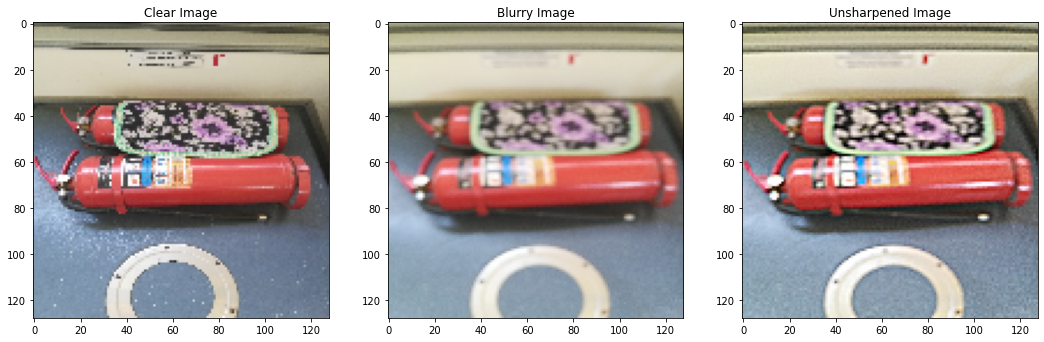

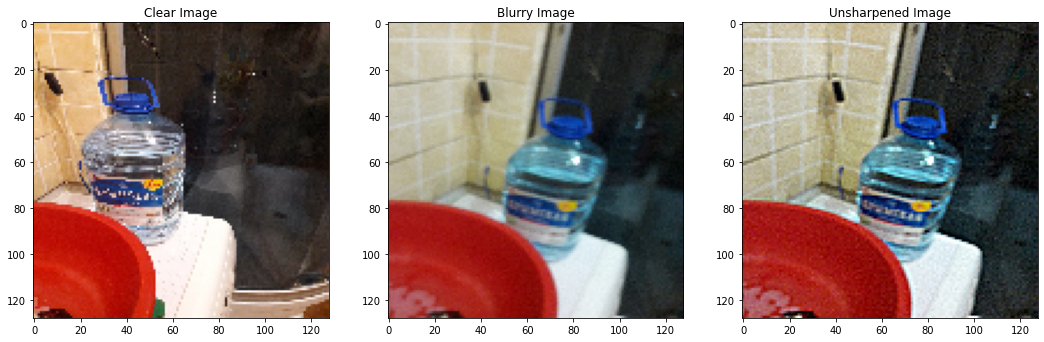

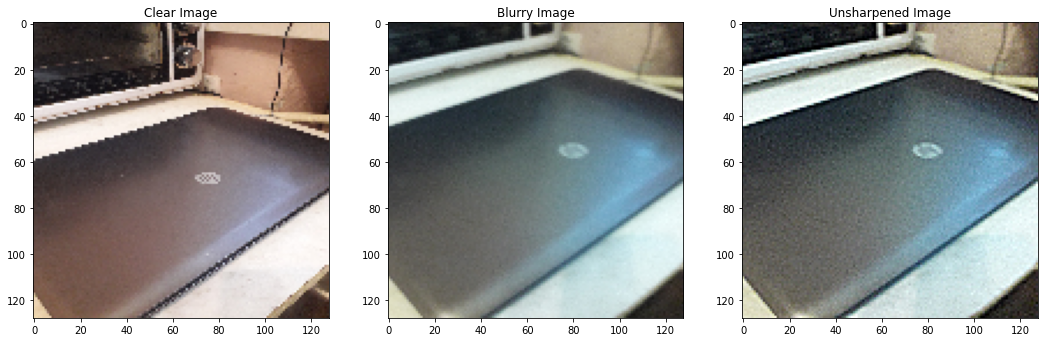

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import cv2
import os
import random
import tensorflow as tf

# Load images from directories
good_frames = 'C:/Users/NIKILESH/Downloads/imgdataset/sharp'
bad_frames = 'C:/Users/NIKILESH/Downloads/imgdataset/defocused_blurred'

clean_frames = []
for file in tqdm(sorted(os.listdir(good_frames))):
    if any(extension in file for extension in ['.jpg', 'jpeg', '.png']):
        image = tf.keras.preprocessing.image.load_img(good_frames + '/' + file, target_size=(128,128))
        image = tf.keras.preprocessing.image.img_to_array(image).astype('float32') / 255
        clean_frames.append(image)

clean_frames = np.array(clean_frames)

blurry_frames = []
for file in tqdm(sorted(os.listdir(bad_frames))):
    if any(extension in file for extension in ['.jpg', 'jpeg', '.png']):
        image = tf.keras.preprocessing.image.load_img(bad_frames + '/' + file, target_size=(128,128))
        image = tf.keras.preprocessing.image.img_to_array(image).astype('float32') / 255
        blurry_frames.append(image)

blurry_frames = np.array(blurry_frames)

# Define unsharp masking function
def apply_unsharp_masking(image, sigma=1.0, alpha=1.5):
    # Gaussian blur
    blurred = cv2.GaussianBlur(image, (5, 5), sigma)
    
    # Unsharp mask
    sharpened = cv2.addWeighted(image, 1 + alpha, blurred, -alpha, 0)
    return sharpened

# MSE calculation
def mse(imageA, imageB):
    return np.mean((imageA - imageB) ** 2)

# PSNR calculation
def psnr(imageA, imageB):
    mse_value = mse(imageA, imageB)
    if mse_value == 0:
        return 100
    PIXEL_MAX = 1.0  # Assuming normalized images (0 to 1 range)
    return 10 * np.log10((PIXEL_MAX ** 2) / mse_value)

# SSIM calculation
def ssim(imageA, imageB):
    C1 = (0.01 * 1.0) ** 2
    C2 = (0.03 * 1.0) ** 2
    
    muA = np.mean(imageA)
    muB = np.mean(imageB)
    
    sigmaA = np.var(imageA)
    sigmaB = np.var(imageB)
    
    sigmaAB = np.mean((imageA - muA) * (imageB - muB))
    
    ssim_value = ((2 * muA * muB + C1) * (2 * sigmaAB + C2)) / ((muA**2 + muB**2 + C1) * (sigmaA + sigmaB + C2))
    return ssim_value

# Visualization of results
print("\n       Input                        Unsharpened Image")
for i in range(3):
    r = random.randint(0, len(clean_frames)-1)
    x, y = blurry_frames[r], clean_frames[r]
    
    # Apply unsharp masking
    sharpened = apply_unsharp_masking((x * 255).astype(np.uint8))
    
    # Calculate MSE, PSNR, and SSIM for original vs blurred
    mse_blurred = mse(x, y)
    psnr_blurred = psnr(x, y)
    ssim_blurred = ssim(x, y)

    # Calculate MSE, PSNR, and SSIM for original vs sharpened (unblurred)
    mse_unblurred = mse(sharpened / 255.0, y)
    psnr_unblurred = psnr(sharpened / 255.0, y)
    ssim_unblurred = ssim(sharpened / 255.0, y)

    print(f"\nImage {r} - Original vs Blurred: MSE={mse_blurred:.4f}, PSNR={psnr_blurred:.4f}, SSIM={ssim_blurred:.4f}")
    print(f"Image {r} - Original vs Unblurred: MSE={mse_unblurred:.4f}, PSNR={psnr_unblurred:.4f}, SSIM={ssim_unblurred:.4f}")

    fig = plt.figure(figsize=(18, 6))
    fig.subplots_adjust(hspace=0.1, wspace=0.2)
    
    # Original Clear Image
    ax = fig.add_subplot(1, 3, 1)
    ax.imshow(y)
    ax.set_title('Clear Image')

    # Blurry Image
    ax = fig.add_subplot(1, 3, 2)
    ax.imshow(x)
    ax.set_title('Blurry Image')

    # Unsharpened Image
    ax = fig.add_subplot(1, 3, 3)
    ax.imshow(sharpened)
    ax.set_title('Unsharpened Image')

plt.show()


100%|██████████| 350/350 [00:05<00:00, 67.57it/s]



       Input                        Unsharpened Image

Image 190 - Original vs Blurred: MSE=0.0094, PSNR=20.2706, SSIM=0.6720
Image 190 - Original vs Unblurred: MSE=0.0135, PSNR=18.6976, SSIM=0.5848

Image 135 - Original vs Blurred: MSE=0.0732, PSNR=11.3537, SSIM=0.5957
Image 135 - Original vs Unblurred: MSE=0.0792, PSNR=11.0147, SSIM=0.5762

Image 105 - Original vs Blurred: MSE=0.0203, PSNR=16.9221, SSIM=0.5361
Image 105 - Original vs Unblurred: MSE=0.0216, PSNR=16.6485, SSIM=0.5219


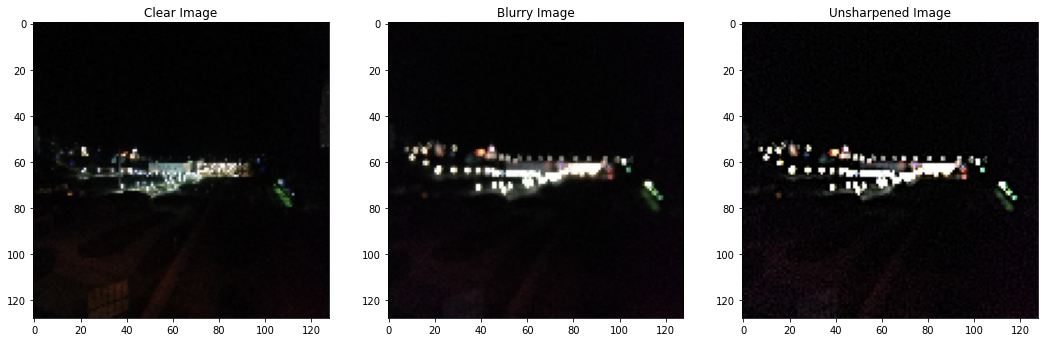

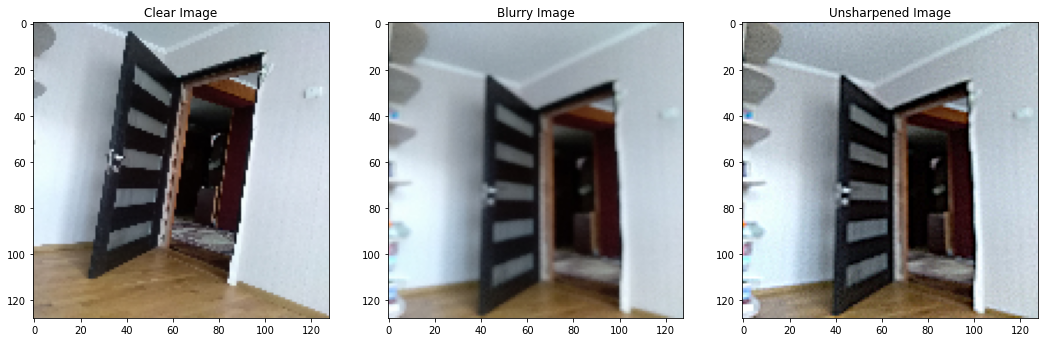

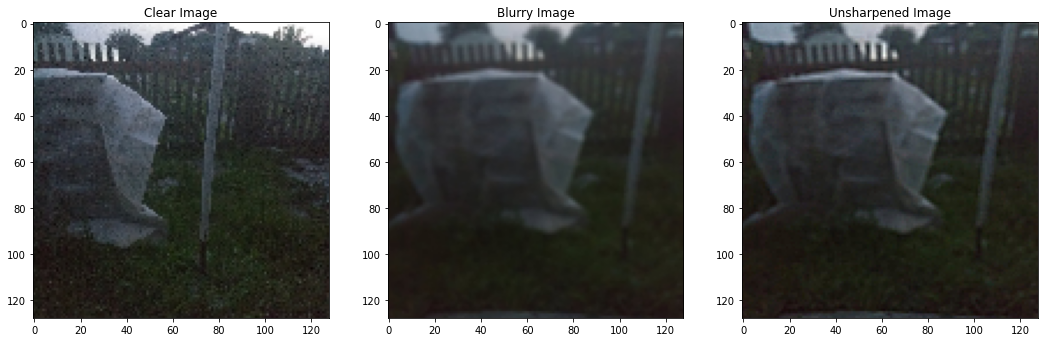

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import cv2
import os
import random
import tensorflow as tf

# Load images from directories
good_frames = 'C:/Users/NIKILESH/Downloads/imgdataset/sharp'
bad_frames = 'C:/Users/NIKILESH/Downloads/imgdataset/defocused_blurred'

clean_frames = []
for file in tqdm(sorted(os.listdir(good_frames))):
    if any(extension in file for extension in ['.jpg', 'jpeg', '.png']):
        image = tf.keras.preprocessing.image.load_img(good_frames + '/' + file, target_size=(128,128))
        image = tf.keras.preprocessing.image.img_to_array(image).astype('float32') / 255
        clean_frames.append(image)

clean_frames = np.array(clean_frames)

blurry_frames = []
for file in tqdm(sorted(os.listdir(bad_frames))):
    if any(extension in file for extension in ['.jpg', 'jpeg', '.png']):
        image = tf.keras.preprocessing.image.load_img(bad_frames + '/' + file, target_size=(128,128))
        image = tf.keras.preprocessing.image.img_to_array(image).astype('float32') / 255
        blurry_frames.append(image)

blurry_frames = np.array(blurry_frames)

# Define unsharp masking function
def apply_unsharp_masking(image, sigma=1.0, alpha=1.5):
    # Gaussian blur
    blurred = cv2.GaussianBlur(image, (5, 5), sigma)
    
    # Unsharp mask
    sharpened = cv2.addWeighted(image, 1 + alpha, blurred, -alpha, 0)
    return sharpened

# MSE calculation
def mse(imageA, imageB):
    return np.mean((imageA - imageB) ** 2)

# PSNR calculation
def psnr(imageA, imageB):
    mse_value = mse(imageA, imageB)
    if mse_value == 0:
        return 100
    PIXEL_MAX = 1.0  # Assuming normalized images (0 to 1 range)
    return 10 * np.log10((PIXEL_MAX ** 2) / mse_value)

# SSIM calculation
def ssim(imageA, imageB):
    C1 = (0.01 * 1.0) ** 2
    C2 = (0.03 * 1.0) ** 2
    
    muA = np.mean(imageA)
    muB = np.mean(imageB)
    
    sigmaA = np.var(imageA)
    sigmaB = np.var(imageB)
    
    sigmaAB = np.mean((imageA - muA) * (imageB - muB))
    
    ssim_value = ((2 * muA * muB + C1) * (2 * sigmaAB + C2)) / ((muA**2 + muB**2 + C1) * (sigmaA + sigmaB + C2))
    return ssim_value

# Visualization of results
print("\n       Input                        Unsharpened Image")
for i in range(3):
    r = random.randint(0, len(clean_frames)-1)
    x, y = blurry_frames[r], clean_frames[r]
    
    # Apply unsharp masking
    sharpened = apply_unsharp_masking((x * 255).astype(np.uint8))
    
    # Calculate MSE, PSNR, and SSIM for original vs blurred
    mse_blurred = mse(x, y)
    psnr_blurred = psnr(x, y)
    ssim_blurred = ssim(x, y)

    # Calculate MSE, PSNR, and SSIM for original vs sharpened (unblurred)
    mse_unblurred = mse(sharpened / 255.0, y)
    psnr_unblurred = psnr(sharpened / 255.0, y)
    ssim_unblurred = ssim(sharpened / 255.0, y)

    print(f"\nImage {r} - Original vs Blurred: MSE={mse_blurred:.4f}, PSNR={psnr_blurred:.4f}, SSIM={ssim_blurred:.4f}")
    print(f"Image {r} - Original vs Unblurred: MSE={mse_unblurred:.4f}, PSNR={psnr_unblurred:.4f}, SSIM={ssim_unblurred:.4f}")

    fig = plt.figure(figsize=(18, 6))
    fig.subplots_adjust(hspace=0.1, wspace=0.2)
    
    # Original Clear Image
    ax = fig.add_subplot(1, 3, 1)
    ax.imshow(y)
    ax.set_title('Clear Image')

    # Blurry Image
    ax = fig.add_subplot(1, 3, 2)
    ax.imshow(x)
    ax.set_title('Blurry Image')

    # Unsharpened Image
    ax = fig.add_subplot(1, 3, 3)
    ax.imshow(sharpened)
    ax.set_title('Unsharpened Image')

plt.show()
